# Figure generation for elevation and aspect delineation

Left column: East River. Right column: Tuolumne River.
Top row: delineated HRUs — hue = aspect class (N-facing cool, S-facing warm), opacity fades with elevation band. Bottom row: the same elevation × aspect grid as a radial schematic.


In [27]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

DATA_ROOT = Path("/scratch/dlhogan/ess-project-data")
FIGDIR = Path("/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/figures/draft")
HRU_ID = "HRU_ID"

BASINS = {
    "East": {
        "domain_dir": DATA_ROOT / "domain_East_River_distributed_elevAspect",
        "shp": "shapefiles/catchment/East_River_distributed_elevAspect_HRUs_elevation_aspect.shp",
        "landclass": "shapefiles/catchment_intersection/with_landclass/catchment_with_landclass.shp",
    },
    "Tuolumne": {
        "domain_dir": DATA_ROOT / "domain_Tuolumne_River_distributed_elevAspect",
        "shp": "shapefiles/catchment/Tuolumne_River_distributed_elevAspect_HRUs_elevation_aspect.shp",
        "landclass": "shapefiles/catchment_intersection/with_landclass/catchment_with_landclass.shp",
    },
}

INK = "#333"
# aspect classes 1=NE 2=SE 3=SW 4=NW; north-facing cool, south-facing warm
ASP_COLOR = {1: "#2c7fb8", 2: "#e6550d", 3: "#b2182b", 4: "#41b6c4", 0: "#bdbdbd"}
ASP_NAME = {1: "NE", 2: "SE", 3: "SW", 4: "NW", 0: "flat"}
ASP_CENTER = {1: 45, 2: 135, 3: 225, 4: 315}
A_HI, A_LO = 1.0, 0.30          # alpha at lowest / highest elevation band


In [2]:
def load(name):
    cfg = BASINS[name]
    # equal-area CRS so the two basins are drawn with undistorted, comparable geometry
    return gpd.read_file(cfg["domain_dir"] / cfg["shp"]).to_crs(5070)


def band_info(g):
    """Ordered elevation bands present on non-flat HRUs, their area-weighted mean elevs, alphas."""
    bands = sorted(g.loc[g.aspectClas > 0, "elevClass"].unique())
    means = np.array([np.average(g.loc[g.elevClass == b, "elev_mean"],
                                 weights=g.loc[g.elevClass == b, "HRU_area"]) for b in bands])
    n = len(bands)
    alphas = np.full(n, A_HI) if n == 1 else np.linspace(A_HI, A_LO, n)
    return bands, means, dict(zip(bands, alphas))


def band_edges(means):
    """Radial band edges from band-mean elevations (midpoints; end bands mirrored)."""
    e = {}
    for i in range(len(means)):
        lo = (means[i-1] + means[i]) / 2 if i > 0 else means[i] - (means[i+1] - means[i]) / 2
        hi = (means[i] + means[i+1]) / 2 if i < len(means)-1 else means[i] + (means[i] - means[i-1]) / 2
        e[i] = (lo, hi)
    return e


ERROR 1: PROJ: proj_create_from_database: Open of /home/dlhogan/miniforge3/envs/ess-project-env/share/proj failed


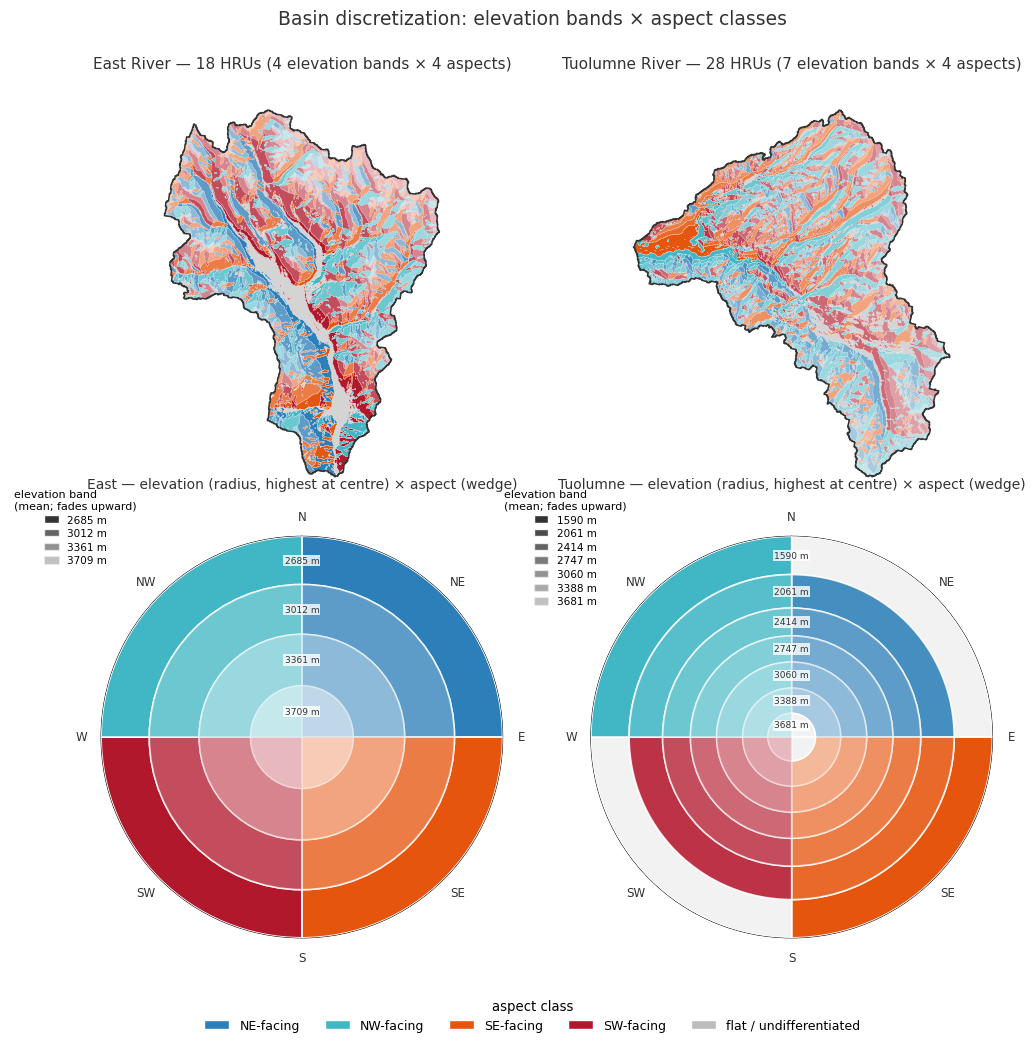

In [3]:
fig = plt.figure(figsize=(11.5, 11))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.10, wspace=0.22)

for j, name in enumerate(BASINS):
    g = load(name)
    bands, means, alpha = band_info(g)
    edges = band_edges(means)

    # ---- top row: map of HRUs, colour = aspect, alpha = elevation band ----
    ax = fig.add_subplot(gs[0, j])
    for (eb, ac), sub in g.groupby(["elevClass", "aspectClas"]):
        a = alpha.get(eb, A_HI) if ac > 0 else 0.65
        sub.plot(ax=ax, facecolor=ASP_COLOR[ac], alpha=a,
                 edgecolor="white", linewidth=0.15, zorder=2)
    # outer basin outline only (exterior rings; interior slivers between HRUs are noise)
    outer = g.geometry.buffer(1).union_all().buffer(-1)
    polys = getattr(outer, "geoms", [outer])
    gpd.GeoSeries([p.exterior for p in polys], crs=g.crs).plot(
        ax=ax, color=INK, linewidth=1.1, zorder=4)
    ax.set_title(f"{name} River — {len(g)} HRUs "
                 f"({len(bands)} elevation bands × 4 aspects)", fontsize=11, color=INK)
    ax.set_axis_off(); ax.set_aspect("equal")

    # ---- bottom row: radial elevation × aspect schematic ----
    axp = fig.add_subplot(gs[1, j], projection="polar")
    axp.set_theta_zero_location("N"); axp.set_theta_direction(-1)
    e_hi = max(hi for _, hi in edges.values()); e_lo = min(lo for lo, _ in edges.values())
    present = set(zip(g.elevClass, g.aspectClas))
    for bi, b in enumerate(bands):
        lo, hi = edges[bi]
        for c in (1, 2, 3, 4):
            filled = (b, c) in present
            axp.bar(np.deg2rad(ASP_CENTER[c]), hi - lo, width=np.deg2rad(90), bottom=e_hi - hi,
                    color=ASP_COLOR[c] if filled else "#f2f2f2", alpha=alpha[b] if filled else 1.0,
                    edgecolor="white", linewidth=1.2, zorder=3, align="center")
    axp.set_rlim(0, e_hi - e_lo); axp.set_yticklabels([]); axp.grid(False)
    axp.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    axp.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"], fontsize=8.5, color=INK)
    for bi, m in enumerate(means):
        lo, hi = edges[bi]
        axp.text(0.0, e_hi - (lo + hi) / 2, f"{int(m)} m", ha="center", va="center",
                 fontsize=6.5, color=INK, zorder=6,
                 bbox=dict(fc="white", ec="none", alpha=0.8, pad=0.8))
    axp.set_title(f"{name} — elevation (radius, highest at centre) × aspect (wedge)",
                  fontsize=10, pad=16, color=INK)

    # elevation-alpha legend, greyscale, one swatch per band of this basin
    elev_handles = [Patch(facecolor=INK, alpha=alpha[b], edgecolor="white",
                          label=f"{int(m)} m") for b, m in zip(bands, means)]
    axp.legend(handles=elev_handles, title="elevation band\n(mean; fades upward)",
               loc="upper left", bbox_to_anchor=(-0.24, 1.14), fontsize=7.5,
               title_fontsize=8, frameon=False, handlelength=1.4, labelspacing=0.35)

# shared aspect legend under the figure
asp_handles = [Patch(facecolor=ASP_COLOR[c], edgecolor="white", label=f"{ASP_NAME[c]}-facing")
               for c in (1, 4, 2, 3)] + \
              [Patch(facecolor=ASP_COLOR[0], edgecolor="white", label="flat / undifferentiated")]
fig.legend(handles=asp_handles, ncol=5, loc="lower center", bbox_to_anchor=(0.5, 0.015),
           frameon=False, fontsize=9, title="aspect class", title_fontsize=9.5)

fig.suptitle("Basin discretization: elevation bands × aspect classes",
             fontsize=13.5, y=0.955, color=INK)
FIGDIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGDIR / "discretization_2x2.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()


In [28]:
# build a model stats dataframe including the aspect, elevation, land cover type (string) and percent area of each HRU
landclass = gpd.read_file(BASINS["Tuolumne"]["domain_dir"] / BASINS["Tuolumne"]["landclass"]).to_crs(5070)

# convert dominant land cover type name using the relevant dictionary
MODIS_IGBP_CLASS_NAMES = {
    0: 'Water',
    1: 'Evergreen Needleleaf Forest',
    2: 'Evergreen Broadleaf Forest',
    3: 'Deciduous Needleleaf Forest',
    4: 'Deciduous Broadleaf Forest',
    5: 'Mixed Forest',
    6: 'Closed Shrublands',
    7: 'Open Shrublands',
    8: 'Woody Savannas',
    9: 'Savannas',
    10: 'Grasslands',
    11: 'Permanent Wetlands',
    12: 'Croplands',
    13: 'Urban and Built-up',
    14: 'Cropland/Natural Vegetation Mosaic',
    15: 'Snow and Ice',
    16: 'Barren or Sparsely Vegetated',
}
landclass['landClass'] = landclass['landClass'].map(MODIS_IGBP_CLASS_NAMES)

# aspect class to string
aspects = {0: 'flat', 1: 'NE', 2: 'SE', 3: 'SW', 4: 'NW'}
landclass['aspectClas'] = landclass['aspectClas'].map(aspects)

# build the table 
landclass_table = landclass.copy()
landclass_table['percent_area'] = landclass_table['HRU_area'] / landclass_table['GRU_area'] * 100
landclass_table.set_index(HRU_ID, inplace=True)


cleaned_column_renames = {'percent_area': "Percent Area",
                          'elev_mean': "Mean Elevation (m)",
                         'aspectClas': "Aspect Class",
                         'landClass': "Dominant Land Cover Class"}
cleaned_landclass_table = landclass_table[['percent_area', 'elev_mean', 'aspectClas', 'landClass']]
cleaned_landclass_table['elev_mean'] = cleaned_landclass_table['elev_mean'].astype(int)
cleaned_landclass_table['percent_area'] = cleaned_landclass_table['percent_area'].round(1)
cleaned_landclass_table = cleaned_landclass_table.rename(columns=cleaned_column_renames)

cleaned_landclass_table

,Percent Area,Mean Elevation (m),Aspect Class,Dominant Land Cover Class
HRU_ID,,,,
1,0.6,3685,SW,Barren or Sparsely Vegetated
2,1.1,3679,NW,Barren or Sparsely Vegetated
3,0.6,3349,flat,Open Shrublands
4,2.1,3395,NE,Barren or Sparsely Vegetated
5,2.3,3387,SE,Barren or Sparsely Vegetated
6,4.3,3390,SW,Open Shrublands
7,3.4,3389,NW,Barren or Sparsely Vegetated
8,3.0,3040,flat,Open Shrublands
9,5.0,3071,NE,Open Shrublands


In [15]:
landclass.columns

Index(['GRU_ID', 'HRU_ID', 'hru_type', 'elevClass', 'aspectClas', 'combined_e',
       'ID', 'gru_to_seg', 'GRU_area', 'HRU_area', 'center_lon', 'center_lat',
       'elev_mean', 'slope_mean', 'IGBP_0', 'IGBP_P0', 'IGBP_1', 'IGBP_P1',
       'IGBP_4', 'IGBP_P4', 'IGBP_5', 'IGBP_P5', 'IGBP_7', 'IGBP_P7',
       'IGBP_10', 'IGBP_P10', 'IGBP_11', 'IGBP_P11', 'IGBP_12', 'IGBP_P12',
       'IGBP_13', 'IGBP_P13', 'IGBP_15', 'IGBP_P15', 'IGBP_16', 'IGBP_P16',
       'count', 'landClass', 'landPct', 'geometry'],
      dtype='object')